<a href="https://colab.research.google.com/github/haritraman/job_fraud_detection_nuerosymbolic/blob/main/emscad_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================= INSTALL =================
!pip install transformers torch pandas scikit-learn numpy gdown matplotlib seaborn -q

# ================= IMPORTS =================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import re
import gdown
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import DistilBertModel, DistilBertTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from torch.utils.data import Dataset, DataLoader

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🔥 Using device:", device)

# ================= LOAD DATA =================
file_id = '15lcwS3slEEmOF6J_D25I3Ed5Oq6zmmdI'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'emscad.csv', quiet=False)

df = pd.read_csv('emscad.csv', encoding='latin-1')
df['text'] = df['title'].fillna('') + " " + df['description'].fillna('')
df['text'] = df['text'].apply(lambda x: re.sub(r'<[^>]+>', '', str(x)).strip())
df['label'] = df['fraudulent'].map({'t': 1, 'f': 0}).astype(int)
df.drop_duplicates(subset=['text'], inplace=True)

print("Class Distribution:\n", df['label'].value_counts())

# ================= SPLIT =================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# ================= DATASET =================
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class JobDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=384,
            return_tensors='pt'
        )

        return {
            'ids': enc['input_ids'].squeeze(0),
            'mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_ds = JobDataset(train_texts, train_labels)
val_ds = JobDataset(val_texts, val_labels)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

# ================= MODEL =================
class DistilBERTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 1)

    def forward(self, ids, mask):
        output = self.bert(input_ids=ids, attention_mask=mask)
        cls = output.last_hidden_state[:,0,:]
        cls = self.dropout(cls)
        return self.classifier(cls)

model = DistilBERTClassifier().to(device)

# ================= OPTIMIZER =================
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 5
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Class Weight
pos_weight = torch.tensor([len(train_labels)/sum(train_labels)]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ================= TRAINING =================
EPOCHS = 5

for epoch in range(EPOCHS):

    print(f"\n🚀 Epoch {epoch+1}/{EPOCHS}")
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(train_loader):

        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(ids, mask)
        loss = loss_fn(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_acc = correct / total
    print(f"🔥 Train Accuracy: {train_acc*100:.2f}%")

# ================= EVALUATION =================
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].unsqueeze(1).to(device)

        outputs = model(ids, mask)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Auto threshold tuning
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("🔥 Best Threshold:", best_threshold)

preds = (np.array(all_probs) > best_threshold).astype(int)

print(classification_report(all_labels, preds))
print("🔥 ROC-AUC:", roc_auc_score(all_labels, all_probs))

🔥 Using device: cuda


Downloading...
From: https://drive.google.com/uc?id=15lcwS3slEEmOF6J_D25I3Ed5Oq6zmmdI
To: /content/emscad.csv
100%|██████████| 59.1M/59.1M [00:00<00:00, 203MB/s]


Class Distribution:
 label
0    15186
1      687
Name: count, dtype: int64


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Epoch 1/5
Batch 0/794 | Loss: 1.6355
Batch 50/794 | Loss: 1.8038
Batch 100/794 | Loss: 1.6255
Batch 150/794 | Loss: 3.7842
Batch 200/794 | Loss: 0.0159
Batch 250/794 | Loss: 4.3675
Batch 300/794 | Loss: 9.1195
Batch 350/794 | Loss: 0.1339
Batch 400/794 | Loss: 0.0640
Batch 450/794 | Loss: 10.3789
Batch 500/794 | Loss: 8.2289
Batch 550/794 | Loss: 6.9293
Batch 600/794 | Loss: 6.8929
Batch 650/794 | Loss: 0.0216
Batch 700/794 | Loss: 0.0378
Batch 750/794 | Loss: 0.0887
🔥 Train Accuracy: 93.77%

🚀 Epoch 2/5
Batch 0/794 | Loss: 11.2415
Batch 50/794 | Loss: 8.1764
Batch 100/794 | Loss: 0.0425
Batch 150/794 | Loss: 0.2717
Batch 200/794 | Loss: 0.0226
Batch 250/794 | Loss: 7.4068
Batch 300/794 | Loss: 0.0137
Batch 350/794 | Loss: 0.0345
Batch 400/794 | Loss: 0.2861
Batch 450/794 | Loss: 0.2375
Batch 500/794 | Loss: 0.2029
Batch 550/794 | Loss: 0.0087
Batch 600/794 | Loss: 0.0785
Batch 650/794 | Loss: 0.0407
Batch 700/794 | Loss: 8.1950
Batch 750/794 | Loss: 0.0025
🔥 Train Accuracy: 97.62%



🔥 Final Validation Accuracy: 98.2992125984252
🔥 Final Validation Loss: 1.6071759144852058
🔥 Best Threshold: 0.0008128637

🔥 Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96      3038
         1.0       0.36      0.91      0.52       137

    accuracy                           0.93      3175
   macro avg       0.68      0.92      0.74      3175
weighted avg       0.97      0.93      0.94      3175

🔥 ROC-AUC: 0.9635228708860517


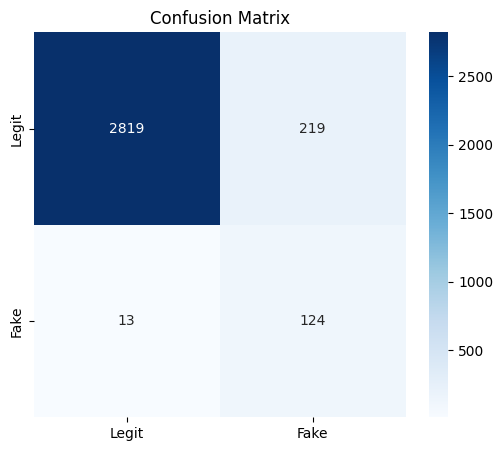

🔥 Fake Detection Rate: 90.51%


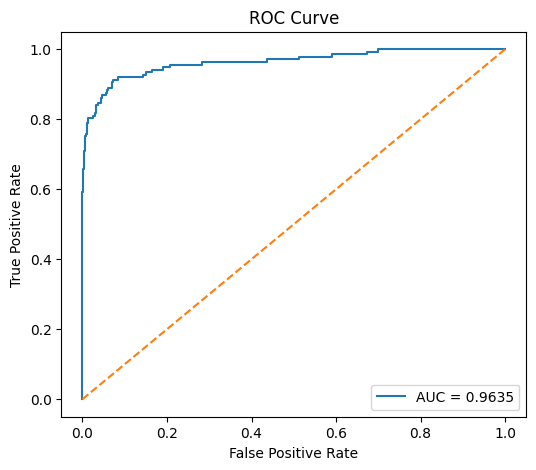

In [ ]:
# ================= FULL EVALUATION =================

model.eval()

all_probs = []
all_labels = []

val_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].unsqueeze(1).to(device)

        outputs = model(ids, mask)
        loss = loss_fn(outputs, labels)

        val_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_accuracy = correct / total
val_loss = val_loss / len(val_loader)

print("\n🔥 Final Validation Accuracy:", val_accuracy * 100)
print("🔥 Final Validation Loss:", val_loss)

# ================= ROC + THRESHOLD TUNING =================

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("🔥 Best Threshold:", best_threshold)

final_preds = (np.array(all_probs) > best_threshold).astype(int)

print("\n🔥 Classification Report:\n")
print(classification_report(all_labels, final_preds))

roc_auc = roc_auc_score(all_labels, all_probs)
print("🔥 ROC-AUC:", roc_auc)

# ================= CONFUSION MATRIX =================

cm = confusion_matrix(all_labels, final_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fake'],
            yticklabels=['Legit','Fake'])
plt.title("Confusion Matrix")
plt.show()

# Fake Detection Rate
fake_detected = cm[1][1]
total_fake = cm[1][0] + cm[1][1]
print(f"🔥 Fake Detection Rate: {(fake_detected/total_fake)*100:.2f}%")

# ================= ROC CURVE =================

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
